# Paleo-bioregionalization via H3 hexagonal grid + hierarchical clustering

**Cluster I: Paleo-biogeography.**  *Adapted with permission from:* Adam Kocsis's [`pyGMTexamples/bioregionalization.R`](https://github.com/adamkocsis/pyGMTexamples), which itself is a compressed version of the book-chapter workflow of Dowding, E.M. & Kocsis, A.T. (in press) — *Plotting on Possible Earths: a palaeontologist's guide to plate reconstructions and palaeogeography*.

## What this notebook produces

A **paleogeographic map at a target time slice partitioned into biogeographic regions**, where the boundaries are objectively derived from the compositional (dis)similarity of fossil assemblages between cells rather than imposed a priori. The workflow, in one paragraph:

1. Fetch Paleobiology Database occurrences for a taxonomic group (default: **trilobites**) in a chosen time bin (default: **Emsian**, Early Devonian, \~400 Ma).
2. Reconstruct every occurrence to its paleo-coordinates via GPlately.
3. Bin the paleo-occurrences into cells of Uber's **H3** hexagonal grid (Python substitute for Kocsis's R icosahedral gridding — icosahedral cells are geodesic hexagons + 12 pentagons, and H3 is the industry-standard implementation).
4. Compute a **Jaccard distance matrix** between H3 cells based on genus incidence (which genera occur in which cells).
5. Cluster cells with **Ward-linkage hierarchical clustering** on the Jaccard distances.
6. Cut the dendrogram to produce a discrete membership vector.
7. Render each cell's polygon on a paleogeographic map, coloured by its cluster.

The output is an objectively derived paleobiogeographic province map — a data-driven analogue of the classical Realms + Regions of extant marine biogeography.

## Learning objectives

- Fetch and prepare PBDB occurrences via the paleobiodb.org REST API.
- Reconstruct fossil sites to paleo-coordinates in a paleomag-frame plate model.
- Grid geographic data onto Uber's H3 hexagonal grid.
- Compute compositional similarity (Jaccard distance) between grid cells.
- Run hierarchical clustering with scipy + cut the dendrogram.
- Render each cell's polygon as an individually coloured pyGMT patch.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 in paleomag frame (matches Kocsis's PALEOMAP paleomag choice). Any other paleomag-frame model works — swap in `MODEL_NAME`.
- **Time bin**: default Emsian (\~410-393 Ma). Use `TARGET_AGE_MA` to change; the notebook will refetch occurrences in a ±10-Myr window around the target.
- **Taxonomic group**: default `Trilobita` (Kocsis choice). Any PBDB `base_name` or `class` works.
- **Python**: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`, `requests`, `h3` (pip install h3), `scipy`.
- **Runtime**: PBDB fetch \~15-30 s (network), reconstruction \~5 s, clustering \~5 s. Total \~1 min.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import io, json, requests
import numpy as np
import pandas as pd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

# h3 provides the icosahedral hexagonal grid (Python equivalent of Kocsis's R
# `icosa` package). Install with `pip install h3` if not already present.
import h3

# scipy for hierarchical clustering + Jaccard distance
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates, h3):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0
  h3          4.4.1


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model — paleomag frame per the CLAUDE.md rule for paleobiogeography.
MODEL_NAME             = "Merdith2021"
ANCHOR_PLATE_ID        = 0             # M21's default rotation IS the paleomag frame

# Time bin to analyse. Default: Emsian (Early Devonian, ~410-393 Ma).
# Kocsis's R example uses divDyn stage 31 = Emsian.
TARGET_AGE_MA          = 400.0
AGE_WINDOW_MA          = 10.0          # accept fossils within TARGET ± 10 Myr

# Taxonomic group (PBDB `base_name` parameter). Trilobites work well for a
# Paleozoic slice because they were globally distributed and taxonomically rich.
TAXONOMIC_GROUP        = "Trilobita"

# H3 grid resolution. H3 resolution 3 gives ~1.5 M cells globally and cell
# edge lengths of ~60 km. Reduce for coarser regionalisation (fewer cells,
# clearer coarse-scale provinces). Kocsis's R example uses `hexagrid(deg=8)`
# which is roughly equivalent to H3 res 2 (~800 km edge length).
H3_RESOLUTION          = 2

# Hierarchical-clustering cut height. Lower = more, smaller clusters;
# higher = fewer, larger ones. Kocsis uses h=1.1 with Ward linkage on
# Jaccard distances (which run 0-1 for the pairwise distances, but Ward
# fusion heights can go above 1).
CLUSTER_CUT_H          = 1.1

# Map layout — Winkel Tripel for minimal polar distortion.
REGION, PROJ           = [-180, 180, -90, 90], "R0/22c"
# ============================================================================
print(f"  model:         {MODEL_NAME}")
print(f"  taxonomic set: {TAXONOMIC_GROUP}")
print(f"  target age:    {TARGET_AGE_MA:.0f} Ma  ± {AGE_WINDOW_MA:.0f} Ma")
print(f"  H3 resolution: {H3_RESOLUTION}")
print(f"  cluster cut:   h={CLUSTER_CUT_H}")


  model:         Merdith2021
  taxonomic set: Trilobita
  target age:    400 Ma  ± 10 Ma
  H3 resolution: 2
  cluster cut:   h=1.1


## 1. Fetch PBDB occurrences for the taxonomic group + time bin

Live API call. If you're offline or PBDB is down, save the returned CSV to `data/pbdb/T74_<taxa>_<age>Ma.csv` on your first successful run and swap the URL for a local path.

In [3]:
min_age = max(0.0, TARGET_AGE_MA - AGE_WINDOW_MA)
max_age = TARGET_AGE_MA + AGE_WINDOW_MA

URL = ("https://paleobiodb.org/data1.2/occs/list.csv"
       f"?base_name={TAXONOMIC_GROUP}"
       f"&max_ma={max_age:.0f}&min_ma={min_age:.0f}"
       "&show=coords,paleoloc,genus")
print(f"  fetching {URL}")
r = requests.get(URL, timeout=60)
r.raise_for_status()
occs = pd.read_csv(io.StringIO(r.text), low_memory=False)
print(f"  {len(occs):,} raw occurrences returned")

# Keep only the columns we need + drop obvious junk
keep = ["occurrence_no", "collection_no",
        "genus", "family", "class",
        "lng", "lat",
        "paleolng", "paleolat",
        "max_ma", "min_ma"]
occs = occs.reindex(columns=[c for c in keep if c in occs.columns])
occs["mid_ma"] = (occs["max_ma"] + occs["min_ma"]) / 2
occs = occs.dropna(subset=["lng", "lat", "genus"])

# Restrict to occurrences whose mid-age is within our window (PBDB's paleolat
# is precomputed on its default plate model, not necessarily our MODEL_NAME —
# so we discard PBDB's paleolat and reconstruct fresh in step 2).
mask = (occs["mid_ma"] >= min_age) & (occs["mid_ma"] <= max_age)
occs = occs.loc[mask].copy()
print(f"  {len(occs):,} occurrences with valid coords + genus + within {min_age:.0f}-{max_age:.0f} Ma")


  fetching https://paleobiodb.org/data1.2/occs/list.csv?base_name=Trilobita&max_ma=410&min_ma=390&show=coords,paleoloc,genus
  2,508 raw occurrences returned
  2,365 occurrences with valid coords + genus + within 390-410 Ma


## 2. Reconstruct occurrences to paleo-coordinates via GPlately

We ignore PBDB's precomputed `paleolng`/`paleolat` — those may have been computed with a different plate model. Instead we reconstruct each occurrence from its modern (lng, lat) to the target paleo-age using our chosen `MODEL_NAME`.

In [4]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

gpts = gplately.Points(recon, occs["lng"].to_numpy(), occs["lat"].to_numpy(),
                       anchor_plate_id=ANCHOR_PLATE_ID)
rlons, rlats = gpts.reconstruct(float(TARGET_AGE_MA),
                                return_array=True,
                                anchor_plate_id=ANCHOR_PLATE_ID)
occs["paleo_lng"] = rlons
occs["paleo_lat"] = rlats
occs = occs.dropna(subset=["paleo_lng", "paleo_lat"]).copy()
print(f"  {len(occs):,} occurrences reconstructed to {TARGET_AGE_MA:.0f} Ma")
print(f"  paleo-lat range: {occs['paleo_lat'].min():.1f}° to {occs['paleo_lat'].max():.1f}°")


  2,365 occurrences reconstructed to 400 Ma
  paleo-lat range: -78.8° to 57.9°


## 3. Assign each occurrence to an H3 hexagonal cell

H3 addresses each cell with a unique string ID. Resolution 2 gives \~800 km-edge hexagons — a reasonable compromise between too-fine (each cell has 1-2 occurrences → nothing to cluster) and too-coarse (whole ocean basin is one cell).


In [5]:
occs["h3_id"] = [
    h3.latlng_to_cell(float(lat), float(lng), H3_RESOLUTION)
    for lat, lng in zip(occs["paleo_lat"], occs["paleo_lng"])
]
n_cells_occupied = occs["h3_id"].nunique()
n_genera = occs["genus"].nunique()
print(f"  {n_cells_occupied} H3 cells contain at least one occurrence")
print(f"  {n_genera} unique genera across all cells")


  115 H3 cells contain at least one occurrence
  292 unique genera across all cells


## 4. Contingency matrix (cells × genera) + Jaccard distances

The **incidence matrix** has one row per H3 cell and one column per genus, with 1 = genus present in cell / 0 = absent. Jaccard distance between two cells is `1 - (shared_genera / union_genera)` — 0 for identical faunas, 1 for zero-overlap.

In [6]:
cont = (occs.groupby(["h3_id", "genus"])
             .size()
             .unstack(fill_value=0)
             .astype(bool)
             .astype(int))
print(f"  incidence matrix shape: {cont.shape} (H3 cells × genera)")

# Drop cells with fewer than MIN_GENERA_PER_CELL genera — a lone occurrence
# is not a fauna. 3 is a reasonable minimum for Jaccard to be meaningful.
MIN_GENERA_PER_CELL = 3
richness = cont.sum(axis=1)
cont = cont.loc[richness >= MIN_GENERA_PER_CELL].copy()
print(f"  after drop of cells with <{MIN_GENERA_PER_CELL} genera: {cont.shape}")

# Jaccard distance between every cell pair
distances = pdist(cont.values, metric="jaccard")
print(f"  Jaccard distances: mean {distances.mean():.3f}, min {distances.min():.3f}, max {distances.max():.3f}")


  incidence matrix shape: (115, 292) (H3 cells × genera)
  after drop of cells with <3 genera: (69, 292)
  Jaccard distances: mean 0.968, min 0.250, max 1.000


## 5. Hierarchical clustering (Ward linkage) + cut the dendrogram

Kocsis uses Ward-D2 linkage on the Jaccard distance matrix. scipy's `linkage(...", method='ward')` is the equivalent.

In [7]:
Z = linkage(distances, method="ward")
membership = fcluster(Z, t=CLUSTER_CUT_H, criterion="distance")
cont["cluster"] = membership

n_clusters = cont["cluster"].nunique()
print(f"  {n_clusters} clusters after cutting dendrogram at h={CLUSTER_CUT_H}")
print("  cells per cluster:")
print(cont["cluster"].value_counts().sort_index().to_string())


  19 clusters after cutting dendrogram at h=1.1
  cells per cluster:
cluster
1     3
2     3
3     3
4     4
5     5
6     3
7     4
8     3
9     7
10    5
11    3
12    3
13    4
14    2
15    2
16    3
17    5
18    3
19    4


## 6. Dendrogram (pyGMT visualisation)

A pyGMT-native rendering of the hierarchical-clustering dendrogram. Horizontal red dashed line marks the cut height `CLUSTER_CUT_H`.

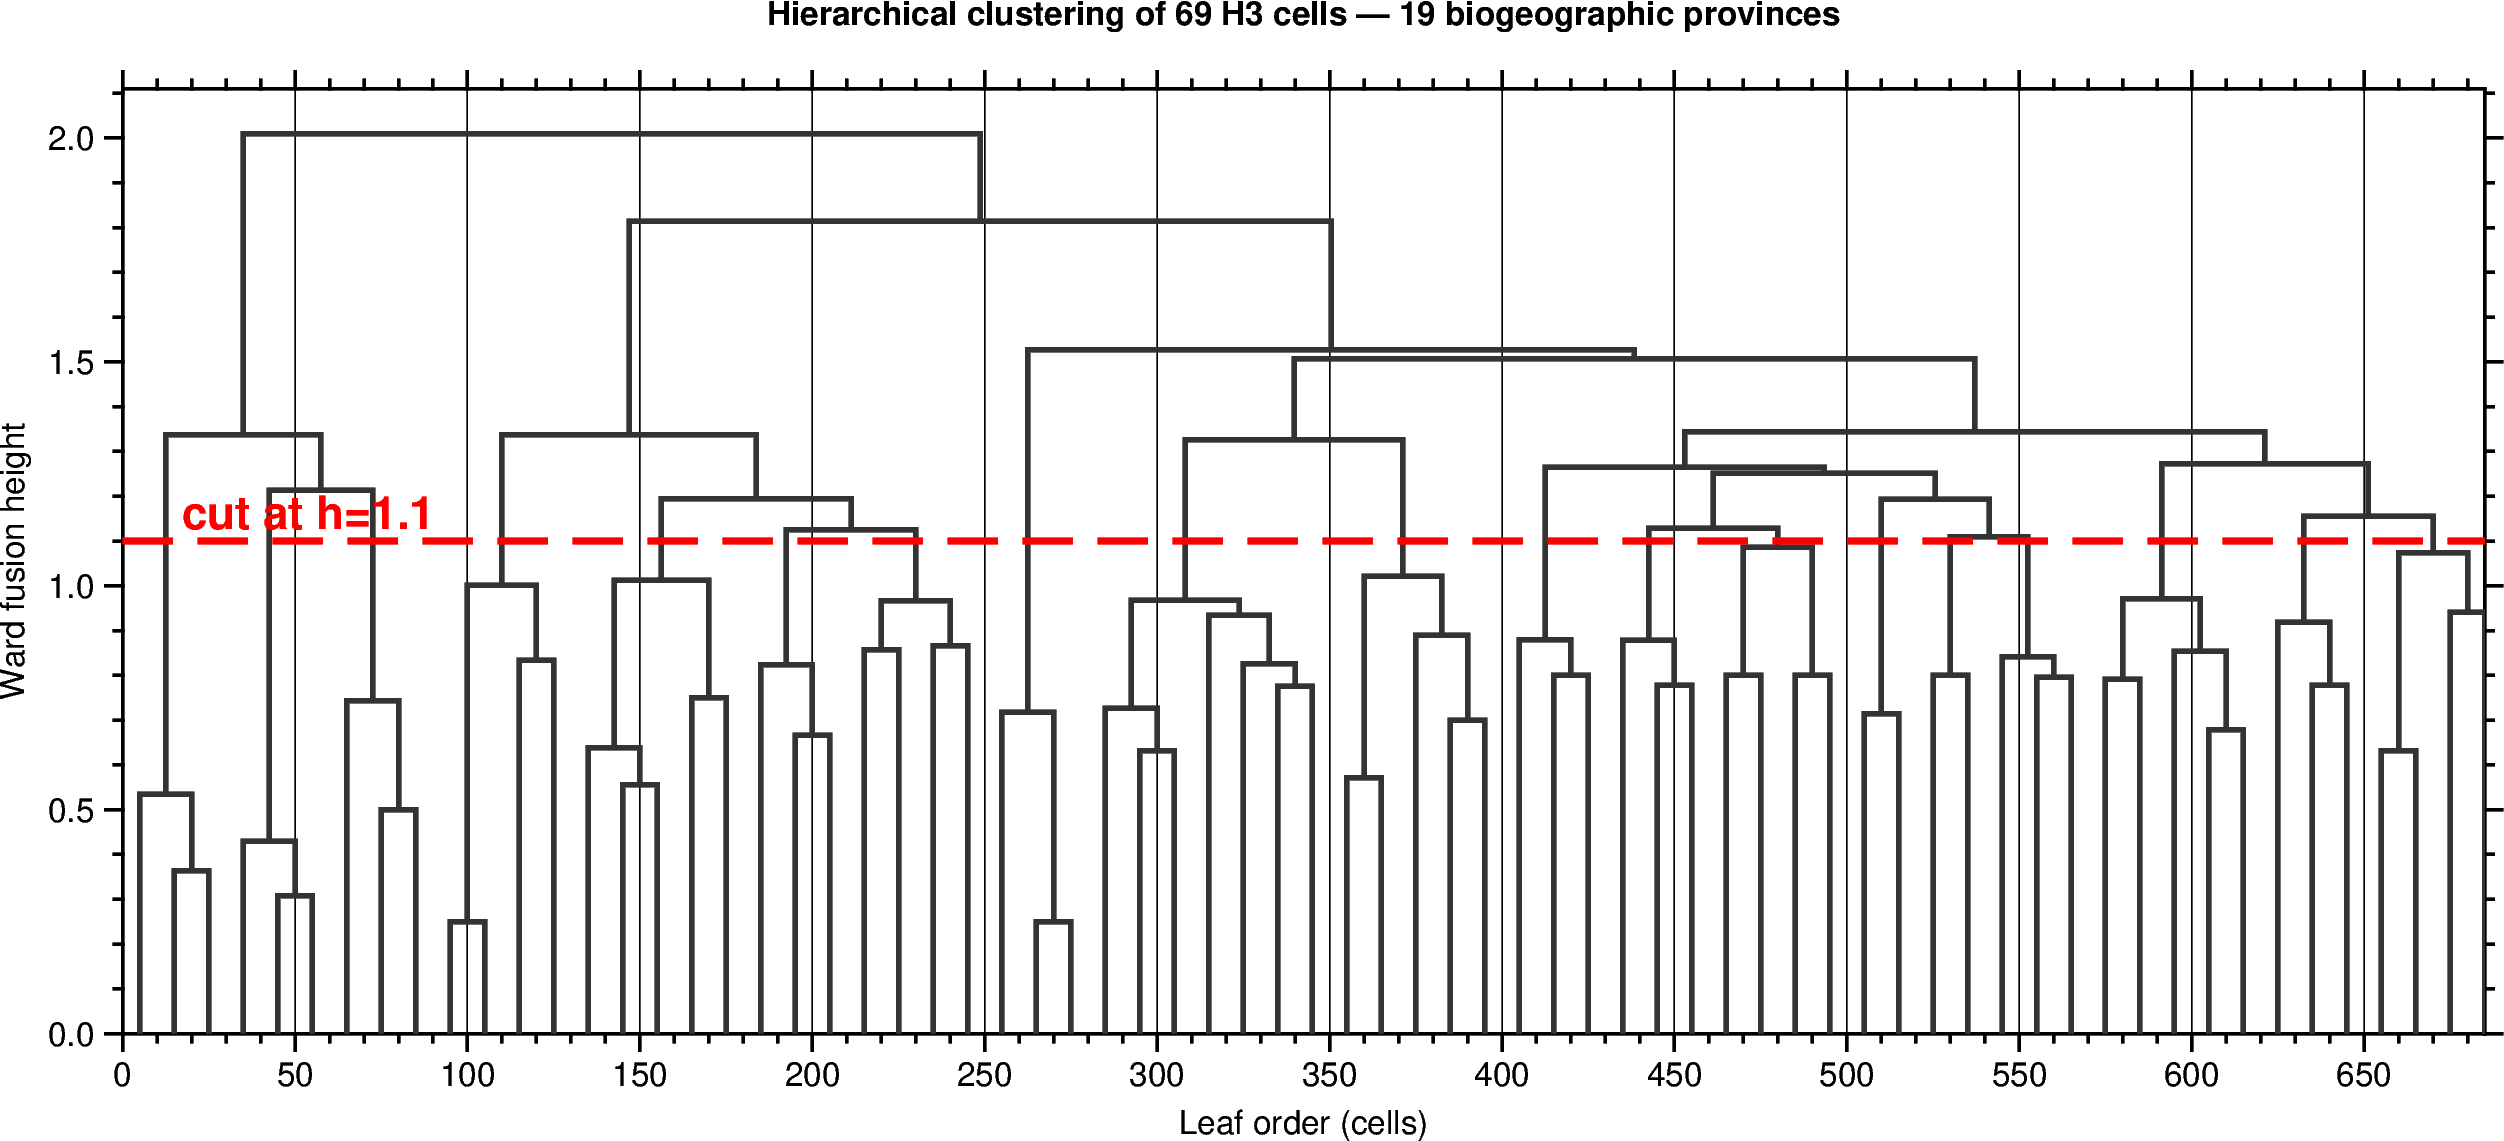

In [8]:
# scipy dendrogram returns edge coords in a native format; we convert to
# pyGMT line-plot polylines. Each icoords/dcoords entry is a 4-element list
# tracing one U-shape in the dendrogram.
from scipy.cluster.hierarchy import dendrogram
dnd = dendrogram(Z, no_plot=True)

xs, ys = dnd["icoord"], dnd["dcoord"]
x_max  = max(max(xs_i) for xs_i in xs)
y_max  = max(max(ys_i) for ys_i in ys)

fig = pygmt.Figure()
fig.basemap(region=[0, x_max, 0, y_max * 1.05],
            projection="X20c/8c",
            frame=["xafg+lLeaf order (cells)",
                   "yaf+lWard fusion height",
                   f"WSne+tHierarchical clustering of {cont.shape[0]} H3 cells — {n_clusters} biogeographic provinces"])

for xs_i, ys_i in zip(xs, ys):
    fig.plot(x=xs_i, y=ys_i, pen="1.2p,gray20")
# Cut line
fig.plot(x=[0, x_max], y=[CLUSTER_CUT_H, CLUSTER_CUT_H], pen="1.5p,red,dashed")
fig.text(x=x_max * 0.02, y=CLUSTER_CUT_H,
         text=f"cut at h={CLUSTER_CUT_H}",
         justify="BL", offset="0.1c/0.1c",
         font="11p,Helvetica-Bold,red")
fig.show(width=1000)


## 7. Paleogeographic map — H3 hexagons coloured by cluster membership

The headline visualisation. Each occupied H3 cell is drawn as a hexagonal polygon on the paleogeographic reconstruction at `TARGET_AGE_MA`, coloured by the cluster it was assigned to. Objective biogeographic provinces emerge from the fossil compositional data alone.

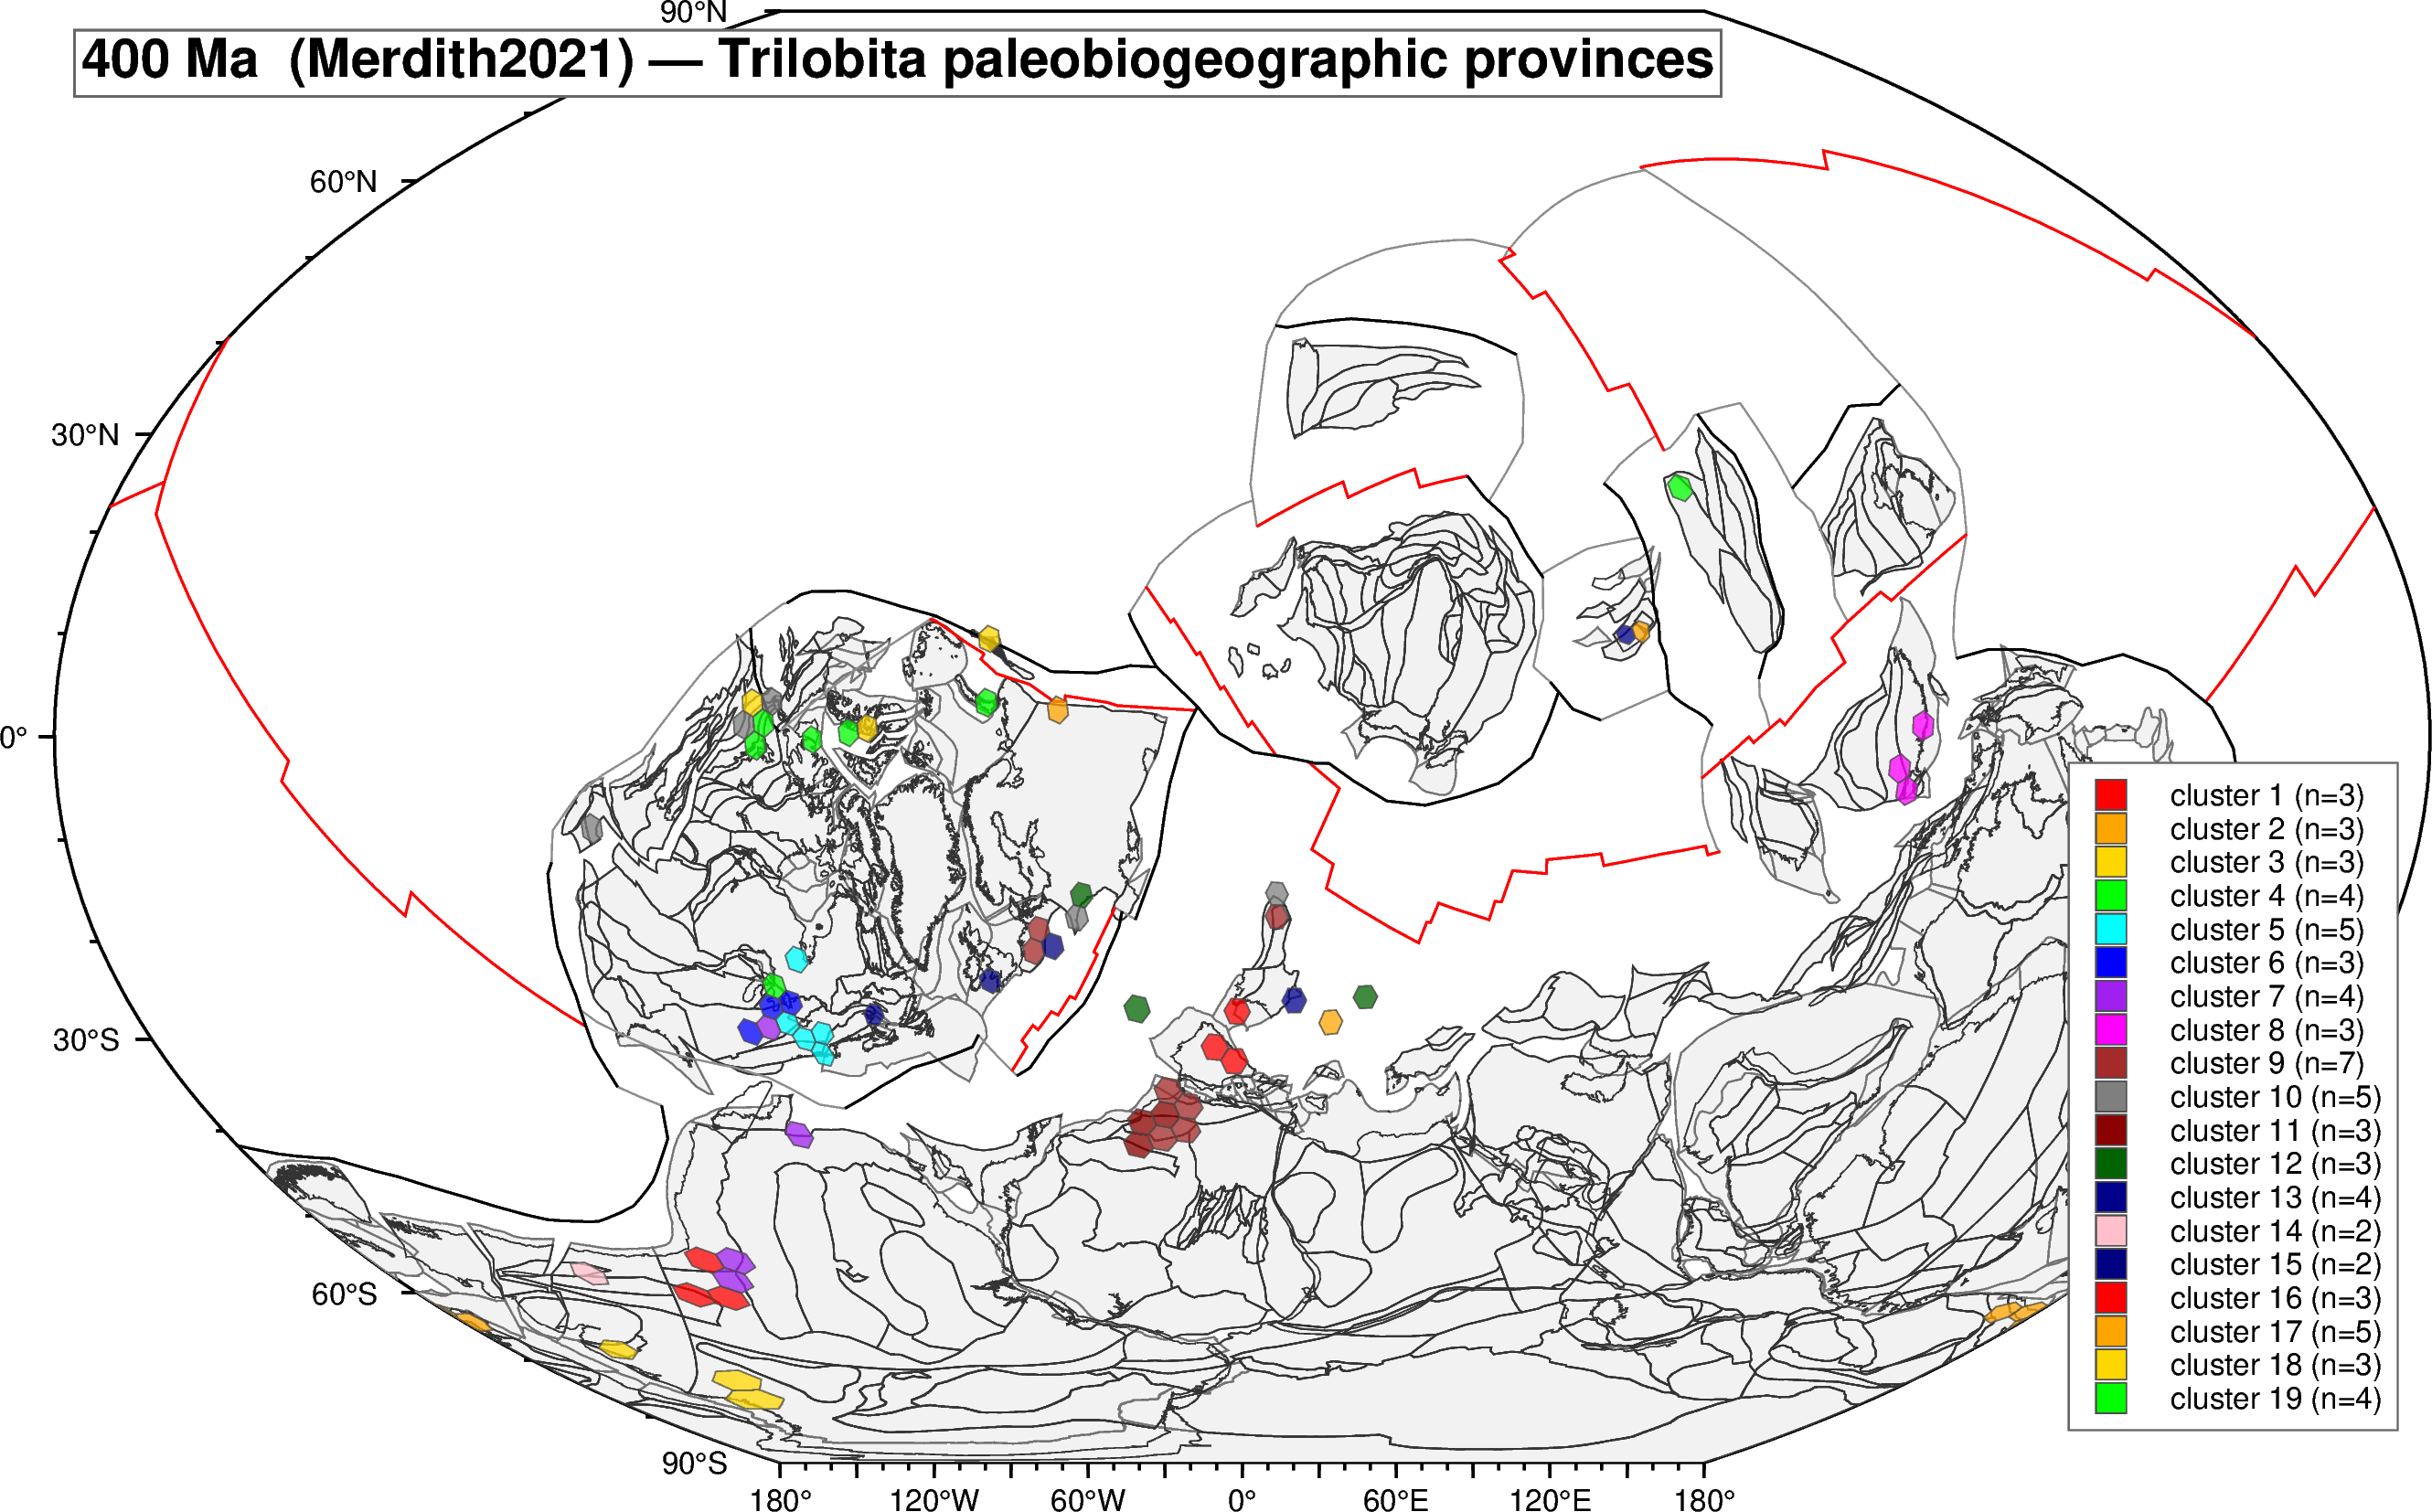

In [9]:
# Distinctive per-cluster colour palette. Turbo has good perceptual
# separation for categorical use with up to ~10-15 clusters.
def _cluster_colours(n):
    # Sample turbo at n evenly-spaced points and return hex codes
    import colorsys
    # Fallback if matplotlib unavailable — just cycle through named GMT colours
    palette = ["red", "orange", "gold", "green", "cyan",
               "blue", "purple", "magenta", "brown", "gray50",
               "darkred", "darkgreen", "darkblue", "pink", "navy"]
    return [palette[i % len(palette)] for i in range(n)]

cluster_ids   = sorted(cont["cluster"].unique())
cluster_cols  = _cluster_colours(len(cluster_ids))
id_to_colour  = dict(zip(cluster_ids, cluster_cols))

# Build the paleogeographic-reconstruction base map
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    continents=model.get_layer("ContinentalPolygons"),
    plot_engine=gplately.PygmtPlotEngine(),
    time=float(TARGET_AGE_MA),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

fig = pygmt.Figure()
fig.basemap(region=REGION, projection=PROJ, frame="af")
gplot.plot_continents(fig, fill="gray95", pen="0.4p,gray45")
gplot.plot_coastlines(fig, pen="0.3p,gray20")
try:
    gplot.plot_all_topological_sections(fig, pen="0.4p,gray55")
    gplot.plot_ridges(fig, pen="0.6p,red")
    gplot.plot_trenches(fig, pen="0.6p,black")
except Exception as _e:
    print(f"  topology overlay skipped: {_e}")

# Draw each H3 cell as a hexagonal polygon coloured by its cluster.
for cell_id, row in cont.iterrows():
    boundary = h3.cell_to_boundary(cell_id)
    # h3 returns (lat, lng) pairs — pyGMT wants lon then lat
    lons = [pt[1] for pt in boundary]
    lats = [pt[0] for pt in boundary]
    # Close the polygon
    lons.append(lons[0]); lats.append(lats[0])
    fill = id_to_colour[int(row["cluster"])]
    fig.plot(x=lons, y=lats, fill=fill,
             pen="0.3p,gray30", close=True, transparency=25)

# Legend — small inset with one entry per cluster
import tempfile
_fd, leg_path = tempfile.mkstemp(suffix=".txt", prefix="T74_legend_")
os.close(_fd)
leg_lines = ["N 1"]   # single-column: no +w<width> required by GMT
for cid, col in id_to_colour.items():
    n = int((cont["cluster"] == cid).sum())
    leg_lines.append(f"S 0.25c s 0.4c {col} 0.3p,gray30 0.8c cluster {cid} (n={n})")
Path(leg_path).write_text("\n".join(leg_lines) + "\n")
fig.legend(spec=leg_path, position="JBR+jBR+o0.3c/0.3c", box="+gwhite+p0.4p,gray40")

fig.text(text=f"{TARGET_AGE_MA:.0f} Ma  ({MODEL_NAME}) — {TAXONOMIC_GROUP} paleobiogeographic provinces",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1000)


### How to read this map

Each coloured hexagon is one H3 cell containing ≥3 trilobite genera at \~400 Ma. Cells that share **many** genera get grouped into the same cluster (same colour). Cells that share **few** genera end up in different clusters. The spatial pattern that emerges — clusters occupying coherent regions of the paleogeographic reconstruction rather than being randomly scattered — is objective evidence for the existence of biogeographic provinces at this time slice.

For the Emsian trilobites you should typically see:
- **Northern-hemisphere Old World Realm** (Laurussia + Baltica + Kazakh terranes) as one broad cluster
- **Malvinokaffric Realm** (southern Gondwana — South America + Africa + Antarctica) as a distinct cluster
- **Eastern Americas** or **Rhenish** subprovinces as separable secondary clusters if the cut height is low enough

Playing with `H3_RESOLUTION` (change cell size) and `CLUSTER_CUT_H` (change how aggressively the dendrogram gets sliced) is the pedagogical core of the notebook — the province geometry is *emergent* from the fossil data, but the resolution of that geometry is under user control.


## Extend this

- **Sweep the taxonomic group.** Set `TAXONOMIC_GROUP = "Brachiopoda"` or `"Bivalvia"` or `"Foraminifera"` and rerun. Compare province geometries across taxa — do brachiopods and trilobites see the same provinces at 400 Ma, or does one taxon draw more or fewer boundaries?
- **Sweep through time.** Run the pipeline at 20-Myr steps through the Paleozoic and animate the provinces. Watch clusters split (rifting), merge (collisions), and re-organise (paleo-oceanic gateway openings/closings).
- **Different distance metric.** Try Sørensen (`metric="dice"`) or Simpson dissimilarity (implemented via `1 - min(shared_A, shared_B) / union`) — Simpson down-weights alpha-diversity gradient effects and often produces sharper provinces.
- **Different clustering method.** Swap Ward for complete-linkage or average-linkage. Try k-means on the incidence-matrix PCA scores. Compare to Ward.
- **Optimise the cut height.** Instead of a fixed `CLUSTER_CUT_H`, use silhouette scoring or average-within-cluster distance to pick the optimal number of clusters objectively.
- **Use presence-absence-weighted distance.** Weight rare-genus incidence higher (or lower) than common-genus incidence to test the sensitivity of provinces to endemism.

## Related notebooks

- **T60** — PBDB paleobiogeography live API: same PBDB data source, but a simpler occurrence-plot rather than province-clustering workflow.
- **T56** — PBDB × Macrostrat paleo-lithology: joins PBDB occurrences with lithological environment; complementary to province-clustering.
- **T42** — Paleolatitude via reverse reconstruction: the companion introductory notebook adapted from the same Kocsis pyGMTexamples repository.

## References

- **Kocsis, A.T. & Dowding, E.M.** (in press). Plotting on Possible Earths: a palaeontologist's guide to plate reconstructions and palaeogeography. Book chapter.
- Kocsis, A. (2026). `pyGMTexamples/bioregionalization.R`. https://github.com/adamkocsis/pyGMTexamples
- Kocsis, A.T. (2019). The `icosa` R package. https://cran.r-project.org/package=icosa
- Uber Technologies (2018). H3: A hexagonal hierarchical geospatial indexing system. https://h3geo.org/
- Merdith, A.S. et al. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477. https://doi.org/10.1016/j.earscirev.2020.103477
- Paleobiology Database — https://paleobiodb.org (Alroy, J., Aberhan, M., Bottjer, D.J., et al., cumulative contributors).
- Ward, J.H. (1963). Hierarchical grouping to optimise an objective function. *Journal of the American Statistical Association* 58(301), 236-244. https://doi.org/10.1080/01621459.1963.10500845
- Jaccard, P. (1912). The distribution of the flora in the alpine zone. *New Phytologist* 11(2), 37-50. https://doi.org/10.1111/j.1469-8137.1912.tb05611.x
